### Imports and Setup

In [1]:
import os

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import yaml
import numpy as np
import torch
from PIL import Image
import pandas as pd

from whale_gunshot_localization.models.tcn_archs import FusionTCN
from whale_gunshot_localization.datasets.dataloaders import get_dataloaders, get_exp_data_dataloader
from whale_gunshot_localization.utils.transformations import get_image_transform, to_spect

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# load config file
from whale_gunshot_localization import config

Using the GPU!


Settings for synthetic data evaluation

In [2]:
split = 'test'

### Prepare For Evaluation
Get dataloaders

In [3]:
dl = get_dataloaders(splits=['train', 'val', 'test'],
                    batch_size=128,
                    shuffle=False,
                    transform=get_image_transform(),
                    squeeze=True,
                    num_workers=20)

Load the desired model

In [4]:
model = FusionTCN(num_inputs=dl[split].dataset.num_TOSSITs,
                num_outputs=2,
                input_size=dl[split].dataset.size[0], 
                output_size=4,
                num_channels=[250, 625] + 3*[368],
                kernel_size=6,
                dropout=0.05).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'] + '/uncertain_unif_block', 'weights_49.pt'),
                        map_location=device)['model_state_dict']
model.load_state_dict(state_dict)

<All keys matched successfully>

## Evaluate Model On Synthetic Data
Get predictions and labels

In [36]:
def evaluate_model(model, dataloader):
    """
    Get lists of targets and predictions using a provided model and dataloader.
    
    Parameters
    ----------
    model : nn.Module
        model to be evaluated
    dataloader : data.DataLoader
        dataloader to use in model evaluation
    
    Returns
    -------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    outputs_all : array-like
        all model outputs
    """
    # put model in evaluatio mode
    model.eval()
    
    # get target scaling values
    max_x = dataloader.dataset.max_x
    max_y = dataloader.dataset.max_y
    
    # initialize arrays for results
    x_t, x_p, y_t, y_p, outputs_all = [], [], [], [], []
    
    # initialize arrays for std
    x_std, y_std = [], []
    
    for inputs, x_targets, y_targets in tqdm(dataloader):
        
        # put data on device
        inputs = inputs.to(device)
        x_targets = x_targets.to(device)
        y_targets = y_targets.to(device)
        
        with torch.set_grad_enabled(False):
            # get outputs and store
            outputs = model(inputs)
            
            outputs_all += outputs.detach().tolist()
            
            # store x predictions and labels
            x_p += (outputs[:,[0]] * max_x).detach().tolist()
            x_t += (x_targets * max_x).detach().tolist()
            
            # store x std
            x_std += (torch.exp(outputs[:,[1]]) * max_x).detach().tolist()
            
            # store y predictions and labels
            y_p += (outputs[:,[2]] * max_y).detach().tolist()
            y_t += (y_targets * max_y).detach().tolist()
            
            # store y std
            y_std += (torch.exp(outputs[:,[3]]) * max_y).detach().tolist()
    
    return np.asarray(x_p), np.asarray(x_std), np.asarray(x_t), np.asarray(y_p), np.asarray(y_std), np.asarray(y_t), np.asarray(outputs_all)

In [6]:
x_p, x_std, x_t, y_p, y_std, y_t, outputs_all = evaluate_model(model, dl[split])

  0%|          | 0/429 [00:00<?, ?it/s]

Plot predicteda and true X/Y componenets and rought predicted and true range

In [7]:
def plot_regressions(x_t, x_p, y_t, y_p, dataloader=None, valid=True):
    """
    Plot regression results.
    
    Parameters
    ----------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    dataloader : torch.utils.data.DataLoader
        dataloader used to produce x_t, x_p, y_t, y_p
    valid : bool
        whether or not to use only valid examples (source at a true bathymetry location)
    """

    if valid:
        # make sure we have a dataloader
        assert dataloader is not None, "dataloader needed to produce valid examples"

        # make sure dataloader is for simulated data
        assert type(dataloader.dataset).__name__ == 'SimData', "'valid' flag only for simulated data."
        
        # get data, labels, and indices of split
        dataset = dataloader.dataset.data
        labels = dataloader.dataset.labels[:]
        idx = dataloader.batch_sampler.idx
        valid_labels = labels[idx,5].astype(int)
        x_t = x_t[valid_labels==1,:]
        x_p = x_p[valid_labels==1,:]
        y_t = y_t[valid_labels==1,:]
        y_p = y_p[valid_labels==1,:]
    
    # convert to km
    x_t = x_t / 1000
    x_p = x_p / 1000
    y_t = y_t / 1000
    y_p = y_p / 1000
    
    # rough range error (assuming flat Earth)
    r_t = np.sqrt(x_t ** 2 + y_t ** 2)
    r_p = np.sqrt(x_p ** 2 + y_t ** 2)
    
    distances = np.sqrt((x_t - x_p) ** 2 + (y_t - y_p) ** 2)
    
    # get endpoints for identity lines
    x_mm = (np.min(x_t), np.max(x_t))
    y_mm = (np.min(y_t), np.max(y_t))
    r_mm = (np.min(r_t), np.max(r_t))
    
    f, (ax1, ax2, ax3) = plt.subplots(1, 3)
    f.set_figheight(4)
    f.set_figwidth(15)
    
    # X component
    ax1.plot(x_t, x_p, 'bo', markersize=2, label="predictions")
    ax1.plot([x_mm[0], x_mm[1]], [x_mm[0], x_mm[1]], 'r--', label="identity line")
    ax1.legend()
    ax1.grid()
    ax1.set_xlabel("True X Component [km]")
    ax1.set_ylabel("Predicted Distance [km]")
    
    # Y component
    ax2.plot(y_t, y_p, 'bo', markersize=2, label="predictions")
    ax2.plot([y_mm[0], y_mm[1]], [y_mm[0], y_mm[1]], 'r--', label="identity line")
    ax2.legend()
    ax2.grid()
    ax2.set_xlabel("True Y Component [km]")
    
    # rough range
    ax3.plot(r_t, r_p, 'bo', markersize=2, label="predictions")
    ax3.plot([r_mm[0], r_mm[1]], [r_mm[0], r_mm[1]], 'r--', label="identity line")
    ax3.legend()
    ax3.grid()
    ax3.set_xlabel("True Rough Range [km]")
    
    plt.figure()
    plt.grid(zorder=3)
    plt.hist(distances, bins='auto', edgecolor='black', zorder=4)
    plt.xlabel("Distance Between Predicted and Ground Truth Location [km]")
    plt.ylabel("Number of Examples")
    
    # calculate component errors
    MSE_X = ((x_t - x_p) ** 2).mean()
    MSE_Y = ((y_t - y_p) ** 2).mean()
    MSE_R = ((r_t - r_p) ** 2).mean()
    
    print("statistics")
    print("-------------------")
    print("MSE (X): {:.3f} km^2".format(MSE_X))
    print("RMSE (X): {:.3f} km".format(np.sqrt(MSE_X)))
    print("-------------------")
    print("MSE (Y): {:.3f} km^2".format(MSE_Y))
    print("RMSE (Y): {:.3f} km".format(np.sqrt(MSE_Y)))
    print("-------------------")
    print("MSE (R): {:.3f} km^2".format(MSE_R))
    print("RMSE (R): {:.3f} km".format(np.sqrt(MSE_R)))
    print("-------------------")

statistics
-------------------
MSE (X): 0.316 km^2
RMSE (X): 0.563 km
-------------------
MSE (Y): 0.056 km^2
RMSE (Y): 0.238 km
-------------------
MSE (R): 0.027 km^2
RMSE (R): 0.164 km
-------------------


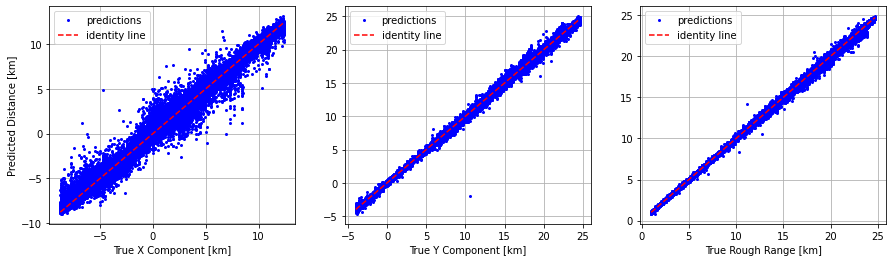

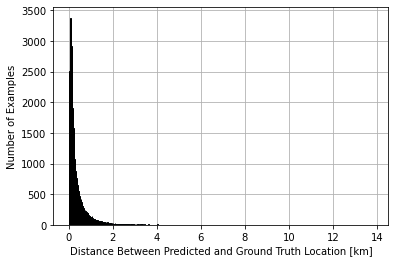

In [8]:
plot_regressions(x_t, x_p, y_t, y_p, dl[split], valid=True)

### Display High Error Calls

In [10]:
def plot_top_k_error(x_t, x_p, x_std, y_t, y_p, y_std, dataloader, k=5, highest=True, valid=True, plot_predicted=False):
    """
    Plot top/bottom-k error calls.
    
    Parameters
    ----------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    dataloader : torch.utils.data.DataLoader
        dataloader used to produce x_t, x_p, y_t, y_p
    k : int
        number of top/bottom error calls to plot
    highest : bool
        whether to plot the highest/lowest error calls
    valid : bool
        whether or not to use only valid examples (source at a true bathymetry location)
    plot_predicted : bool
        whether or not to plot the predicted or group truth gunshot locations
    """
    
    # get data, labels, and indices of split
    dataset = dataloader.dataset.data
    labels = dataloader.dataset.labels[:]
    
    if type(dataloader.dataset).__name__ == 'SimData':
        idx = dataloader.batch_sampler.idx
    else:
        idx = np.arange(dataset.shape[0])
        
    assert len(idx) >= k, "k must be <= the number of exampes in the dataset"
    
    # get valid examples only
    if valid:
        # make sure we have a dataloader
        assert dataloader is not None, "dataloader needed to produce valid examples"
        
        # make sure dataloader is for simulated data
        assert type(dataloader.dataset).__name__ == 'SimData', "'valid' flag only for simulated data."
        
        valid_labels = labels[idx,5].astype(int)
        x_t = x_t[valid_labels == 1,:]
        x_p = x_p[valid_labels == 1,:]
        y_t = y_t[valid_labels == 1,:]
        y_p = y_p[valid_labels == 1,:]
        idx = idx[valid_labels == 1]
    
    # sum X/Y absolute errors and get indices from largest to smallest
    top_k_abs_err = np.sqrt((x_t - x_p) ** 2 + (y_t - y_p) ** 2)
    inds = top_k_abs_err.squeeze().argsort()[::-1][:k] if highest else top_k_abs_err.squeeze().argsort()[:k]
    
    # get number of sensors per call
    num_TOSSITs = dataset.shape[1]
    
    # initialize dataframe
    df = pd.DataFrame(columns=["GT-P Distance [m]", 
                               "Y-Component GT [m]",
                               "Y-Component P [m]",
                               "Y-Component Abs. Error [m]",
                               "Y-Component $\sigma$ [m]",
                               "X-Component GT [m]",  
                               "X-Component P [m]",
                               "X-Component Abs. Error [m]",
                               "X-Component $\sigma$ [m]"])
    
    x_list, y_list = [], []
    for d in range(k):
        
        # store coordinates
        top_k_X = dataset[idx[inds[d]],...]
        if plot_predicted:
            x_list.append(x_p[inds[d]])
            y_list.append(y_p[inds[d]])
        else:
            x_list.append(labels[idx[inds[d]],1])
            y_list.append(labels[idx[inds[d]],0])
        
        # append row to dataframe
        df_row = pd.DataFrame({"GT-P Distance [m]": [np.around(top_k_abs_err[inds[d]][0], 2)],
                               "Y-Component GT [m]": [np.around(y_t[inds[d]].squeeze(), 2)],
                               "Y-Component P [m]": [np.around(y_p[inds[d]].squeeze(), 2)],
                               "Y-Component Abs. Error [m]": [np.around(np.abs(y_t[inds[d]].squeeze() - y_p[inds[d]].squeeze()), 2)],
                               "Y-Component $\sigma$ [m]": [np.around(y_std[inds[d]].squeeze(), 2)],
                               "X-Component GT [m]": [np.around(x_t[inds[d]].squeeze(), 2)],
                               "X-Component P [m]": [np.around(x_p[inds[d]].squeeze(), 2)],
                               "X-Component Abs. Error [m]": [np.around(np.abs(x_t[inds[d]].squeeze() - x_p[inds[d]].squeeze()), 2)],
                               "X-Component $\sigma$ [m]": [np.around(x_std[inds[d]].squeeze(), 2)]})
        df = pd.concat([df, df_row], ignore_index=True)
        
        # only plot signals if fewer than 20 calls
        if k < 20:
            plt.figure()
            for t in range(num_TOSSITs):
                spect = to_spect(top_k_X[t])
                plt.subplot(1,num_TOSSITs, t+1)
                plt.imshow(spect.squeeze())
                plt.title(f"TOSSIT {t+1}")
                plt.axis('off')
            plt.tight_layout()
    
    # show dataframe tail if less than 20 signals
    if k < 20:
        display(df)
    else:
        display(df.head())
    
    # get correct location label for plot
    loc_label = 'predicted' if plot_predicted else 'ground truth' 
    
    # overlay points onto map
    plt.figure()
    img = Image.open(config['dataset']['data_directory'] + '/map.tif', mode='r', formats=None)
    plt.scatter(x_list, y_list, c='#0307fc', s=2, label=loc_label)
    plt.scatter(np.asarray(config['TOSSIT']['TOSSIT_x']), np.asarray(config['TOSSIT']['TOSSIT_y']), s=30, marker='x', label='TOSSIT')
    plt.gca().invert_yaxis()
    implot = plt.imshow(img, extent=(config['scaling']['min_x'], config['scaling']['max_x'], config['scaling']['max_y'], config['scaling']['min_y']))
    plt.legend(loc='lower left')
    plt.xlabel("X Component [m]")
    plt.ylabel("Y Component [m]")

,GT-P Distance [m],Y-Component GT [m],Y-Component P [m],Y-Component Abs. Error [m],Y-Component $\sigma$ [m],X-Component GT [m],X-Component P [m],X-Component Abs. Error [m],X-Component $\sigma$ [m]
0,13828.56,10563.48,-1908.68,12472.16,529.22,3448.02,9420.82,5972.80,174.54
1,10252.80,19459.05,16056.88,3402.17,554.07,-4764.23,4907.65,9671.88,1064.42
2,7990.83,13528.67,13162.68,365.99,181.87,-6760.95,1221.50,7982.45,491.66
3,7419.00,22331.58,23986.50,1654.92,253.55,8427.11,1195.05,7232.07,1106.12
4,6986.11,22146.25,22717.85,571.60,314.74,6907.29,-55.39,6962.68,1494.12
5,6360.96,23350.86,22187.34,1163.52,423.20,1243.52,7497.17,6253.65,737.51
6,6204.41,21590.28,21812.47,222.19,330.71,-6285.14,-84.71,6200.43,1956.59
7,6143.64,22980.21,22998.22,18.01,335.52,5111.99,-1031.62,6143.61,1606.48
8,6088.34,22609.56,23141.41,531.85,408.96,7253.13,1188.06,6065.07,1740.41
9,5978.59,22794.89,21247.20,1547.69,443.38,1865.14,7639.93,5774.79,1068.42


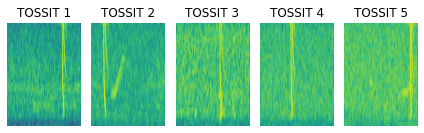

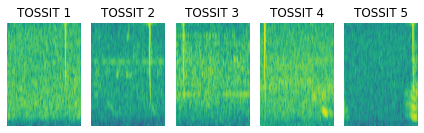

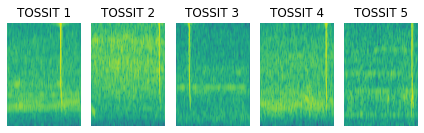

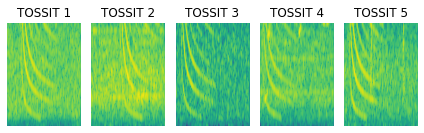

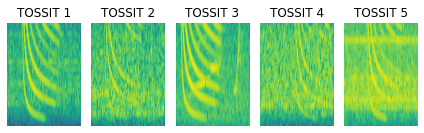

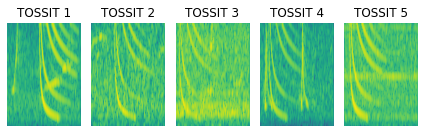

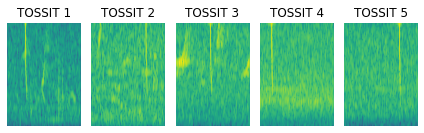

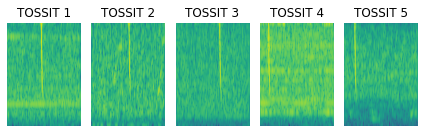

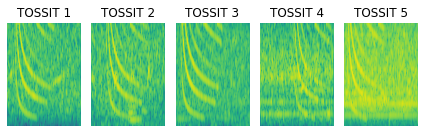

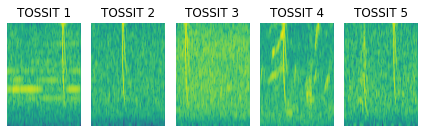

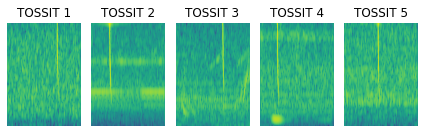

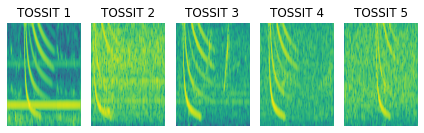

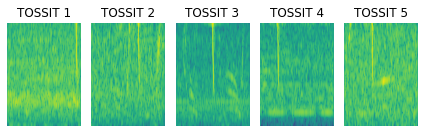

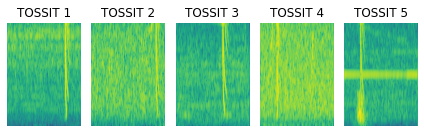

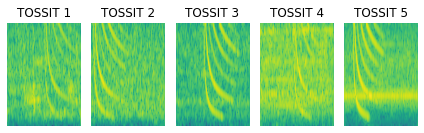

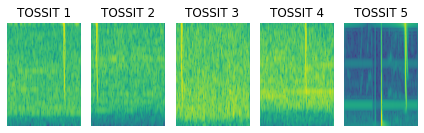

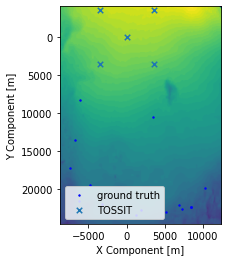

In [11]:
plot_top_k_error(x_t, 
                 x_p,
                 x_std,
                 y_t, 
                 y_p,
                 y_std,
                 dl[split],
                 highest=True,
                 k=16,
                 valid=True)

## Evaluation Model On Experimental Data

get dataloaders

In [12]:
dl_exp = get_exp_data_dataloader(batch_size=128, transform=get_image_transform(), squeeze=True)

get predictions and labels

In [37]:
x_p, x_std, x_t, y_p, y_std, y_t, outputs_all = evaluate_model(model, dl_exp)

  0%|          | 0/1 [00:00<?, ?it/s]

Plot predicteda and true X/Y componenets and rought predicted and true range

/opt/conda/lib/python3.8/site-packages/matplotlib/axes/_axes.py:6613: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/opt/conda/lib/python3.8/site-packages/matplotlib/axes/_axes.py:6614: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

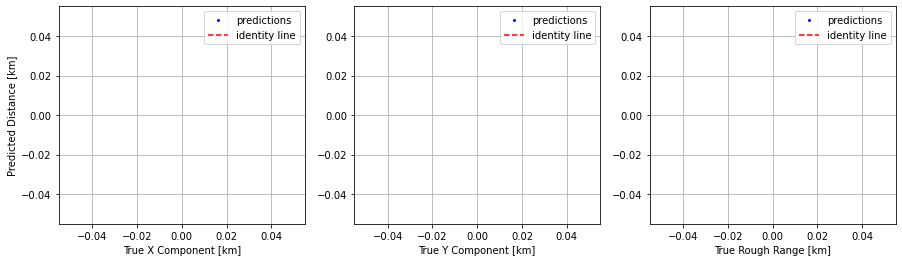

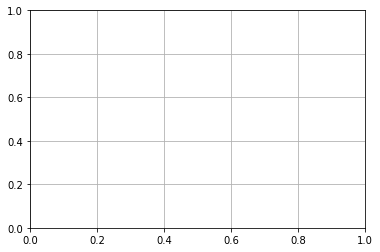

In [14]:
plot_regressions(x_t, x_p, y_t, y_p, dl_exp, valid=False)

In [ ]:
plot_top_k_error(x_t, 
                 x_p,
                 x_std,
                 y_t, 
                 y_p,
                 y_std,
                 dl_exp,
                 highest=True,
                 k=1,
                 valid=False,
                 plot_predicted=True)

,GT-P Distance [m],Y-Component GT [m],Y-Component P [m],Y-Component Abs. Error [m],Y-Component $\sigma$ [m],X-Component GT [m],X-Component P [m],X-Component Abs. Error [m],X-Component $\sigma$ [m]
0,NaN,NaN,-4000.67,NaN,422.04,NaN,3244.97,NaN,301.77
